#An Analysis of Global COVID-19 Vaccination Progress
#Project Goal & Problem Statement
This project undertakes a comprehensive exploratory data analysis of the global COVID-19 vaccination rollout, using a real-world dataset on COVID-19 Vaccinations. The primary objective is to clean, process, and visualize this complex time-series data to uncover key trends, compare national strategies, and understand the overall trajectory of one of the largest public health campaigns in history.

**We will structure our analysis to answer several key analytical questions:**

1. What is the overall timeline and scale of the global vaccination effort?

2. Which countries were the leaders in both total vaccinations and per-capita vaccination rates?

3. Which specific vaccines formed the backbone of the global campaign?

4. How did the rollout speed and efficiency compare between different nations?

5. Is there a correlation between a country's economic strength and its vaccination success?

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter

df = pd.read_csv('country_vaccinations.csv')

df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2/22/2021,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2/23/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2/24/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2/25/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2/26/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


**Initial Data Inspection & Health Check**
Before any analysis can begin, we must perform a high-level "health check" on the dataset. This initial inspection is crucial for understanding the data's structure, identifying its limitations, and forming a strategy for cleaning and preprocessing. We will use the .info() and .isnull().sum() methods to answer two key questions:

**Data Types:** Are the columns in the correct format? (e.g., Is the date column actually a date?)

**Missing Values:** How complete is the data? Which columns have significant missing values that we will need to address?

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86512 entries, 0 to 86511
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              86512 non-null  object 
 1   iso_code                             86512 non-null  object 
 2   date                                 86512 non-null  object 
 3   total_vaccinations                   43607 non-null  float64
 4   people_vaccinated                    41294 non-null  float64
 5   people_fully_vaccinated              38802 non-null  float64
 6   daily_vaccinations_raw               35362 non-null  float64
 7   daily_vaccinations                   86213 non-null  float64
 8   total_vaccinations_per_hundred       43607 non-null  float64
 9   people_vaccinated_per_hundred        41294 non-null  float64
 10  people_fully_vaccinated_per_hundred  38802 non-null  float64
 11  daily_vaccinations_per_milli

In [117]:
df.isnull().sum()

,0
country,0
iso_code,0
date,0
total_vaccinations,42905
people_vaccinated,45218
people_fully_vaccinated,47710
daily_vaccinations_raw,51150
daily_vaccinations,299
total_vaccinations_per_hundred,42905
people_vaccinated_per_hundred,45218


**Data Cleaning and Preprocessing**
The initial inspection revealed two critical data quality issues: the date column was stored as text, and key metrics like daily_vaccinations and total_vaccinations had a significant number of missing values.

This section implements a robust, analytically sound cleaning strategy:

Date Conversion: The date column is converted to a proper datetime format, enabling correct time-series sorting and plotting.

Intelligent Imputation: A simple fillna(0) would be incorrect, as it would create artificial drops in the data. Instead, we apply a grouped forward-fill (ffill). This is the standard method for time-series data with reporting lags; it assumes that the value on a non-reported day is the same as the last known value. Any remaining NaNs at the very beginning of a country's timeline are then safely filled with 0.

In [118]:
# --- 1. Convert 'date' column to datetime objects ---
df['date'] = pd.to_datetime(df['date'])
print("Converted 'date' column to datetime format.")

# --- 2. Sort the DataFrame ---
# Crucial for correct time-series processing.
df = df.sort_values(['country', 'date'])
print("DataFrame sorted by country and date.")

# --- 3. Identify ALL time-series columns that need imputation ---
# This is a more robust list of all columns that represent a running count or daily value.
metrics_to_fill = [
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'daily_vaccinations_raw',
    'daily_vaccinations',
    'total_vaccinations_per_hundred',
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'daily_vaccinations_per_million'
]

# --- 4. Intelligent Imputation for ALL Core Metrics ---
# We apply the same robust logic to every metric column.
print("Applying forward-fill to all time-series metrics...")
for col in metrics_to_fill:
    # Check if column exists before trying to fill it
    if col in df.columns:
        df[col] = df.groupby('country')[col].ffill()

# --- 5. Handle Remaining NaNs ---
# Any remaining NaNs at the beginning of a country's timeline can now be safely filled with 0.
df[metrics_to_fill] = df[metrics_to_fill].fillna(0)
print("Filled remaining initial NaNs with 0.")


# --- 6. Final Verification ---
# Let's check the total number of missing values in the entire DataFrame.
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("\nSUCCESS: The entire DataFrame is now clean with zero missing values.")
else:
    # This will show us if any columns we didn't expect still have missing data
    print("\nWARNING: Some missing values still remain in the following columns:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Converted 'date' column to datetime format.
DataFrame sorted by country and date.
Applying forward-fill to all time-series metrics...
Filled remaining initial NaNs with 0.

SUCCESS: The entire DataFrame is now clean with zero missing values.


In [119]:
df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,0.0,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,0.0,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,0.0,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,0.0,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [120]:
df.isnull().sum()

,0
country,0
iso_code,0
date,0
total_vaccinations,0
people_vaccinated,0
people_fully_vaccinated,0
daily_vaccinations_raw,0
daily_vaccinations,0
total_vaccinations_per_hundred,0
people_vaccinated_per_hundred,0


**Exploratory Data Analysis: Global & National Trends**

With a clean and complete dataset, we can now begin our analysis. We will start with a high-level global overview and then drill down to compare the performance of individual nations.

Question 1: What was the global vaccination trend over time?

The following line chart aggregates the daily vaccinations from all countries to visualize the overall trajectory of the global campaign, showing its initial ramp-up and subsequent peaks.

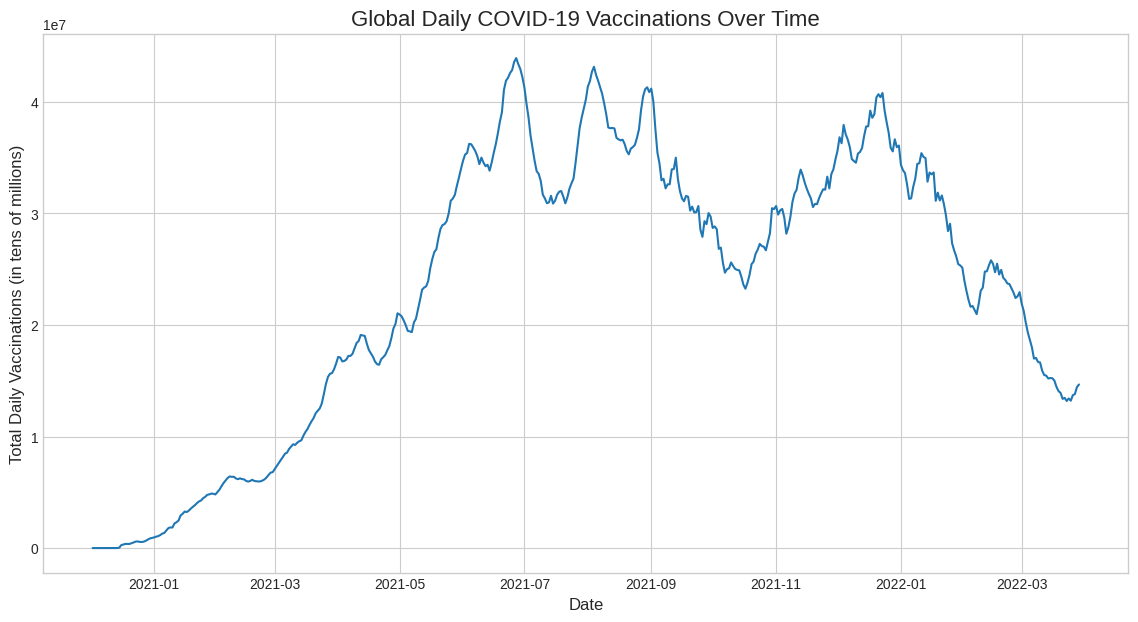

In [121]:
# --- Aggregate data to the global level ---
# We group by date and sum the daily vaccinations to get a global daily total.
global_daily_vaccinations = df.groupby('date')['daily_vaccinations'].sum().reset_index()

# --- Create the plot ---
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='daily_vaccinations', data=global_daily_vaccinations)

plt.title('Global Daily COVID-19 Vaccinations Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Vaccinations (in tens of millions)', fontsize=12)
plt.show()


In [122]:
# --- Find the latest total vaccination number for each country ---
# We group by location and find the maximum 'total_vaccinations' recorded for each.
latest_totals = df.groupby('country')['total_vaccinations'].max().reset_index()

# --- Create the interactive world map ---
# We use a log scale for the color to better visualize the vast differences between countries.
fig = px.choropleth(latest_totals,
                    locations="country",
                    locationmode='country names',
                    color="total_vaccinations",
                    hover_name="country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='Total COVID-19 Vaccinations by Country',
                    labels={'total_vaccinations': 'Total Vaccinations'})

fig.show()


In [123]:
# --- Find the latest total vaccination number PER HUNDRED for each country ---
# We group by location and find the maximum 'total_vaccinations_per_hundred' recorded for each.
# This is a more insightful metric than the raw total.
latest_totals_per_hundred = df.groupby('country')['total_vaccinations_per_hundred'].max().reset_index()

# --- Create the interactive world map ---
# We now color the map based on the vaccinations per 100 people.
fig = px.choropleth(latest_totals_per_hundred,
                    locations="country",
                    locationmode='country names',
                    color="total_vaccinations_per_hundred",
                    hover_name="country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='Total COVID-19 Vaccinations per 100 People by Country',
                    labels={'total_vaccinations_per_hundred': 'Vaccinations per 100 People'})

fig.show()



**Question: Which vaccines were most widely adopted?**

The vaccines column contains a list of the specific vaccines used in each country's campaign. By parsing this text data and counting the occurrences of each vaccine, we can create a bar chart to identify which vaccines formed the backbone of the global effort, based on the number of countries that approved and used them.

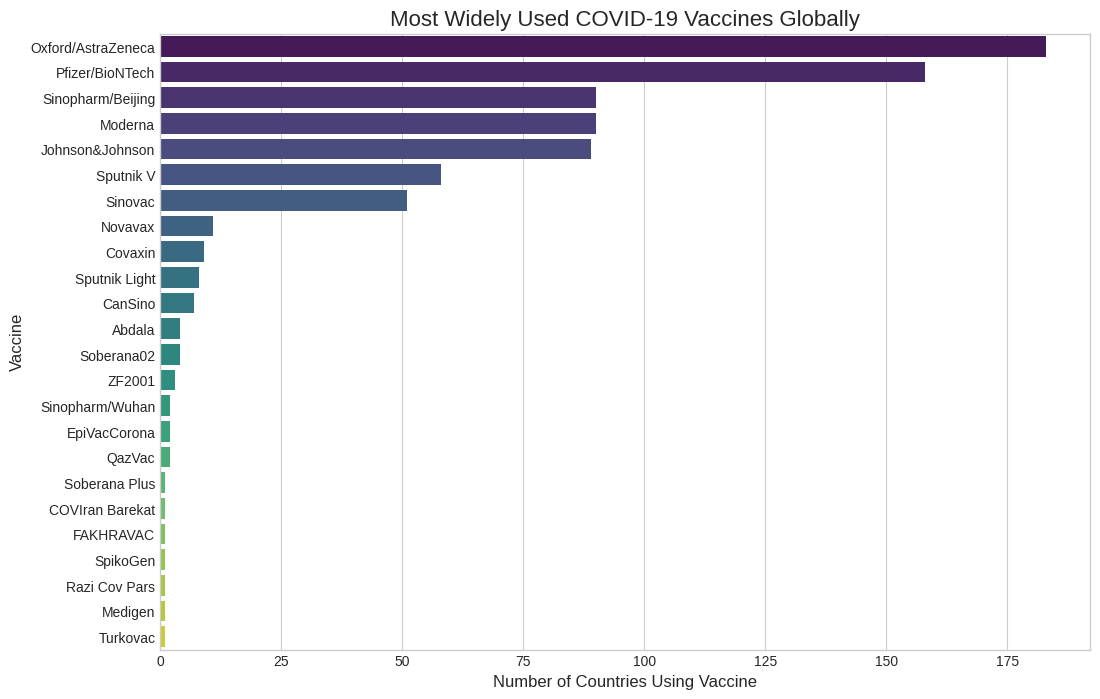

In [152]:
# --- 1. Process the 'vaccines' column ---
# Get the latest vaccine list used by each country to avoid over-counting.
latest_vaccines = df.groupby('country')['vaccines'].last().dropna()

# Create a list to hold every mention of each vaccine.
vaccine_list = []
for vaccines in latest_vaccines:
    # Split the string by commas and strip any leading/trailing whitespace.
    vaccine_list.extend([vaccine.strip() for vaccine in vaccines.split(',')])

# --- 2. Count the occurrences of each vaccine ---
# The Counter object is a specialized dictionary for counting.
vaccine_counts = Counter(vaccine_list)
vaccine_df = pd.DataFrame.from_dict(vaccine_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

# --- 3. Create the bar chart ---
plt.figure(figsize=(12, 8))
sns.barplot(x=vaccine_df['count'], y=vaccine_df.index, hue=vaccine_df.index, palette='viridis')
plt.xlabel('Number of Countries Using Vaccine', fontsize=12)
plt.title('Most Widely Used COVID-19 Vaccines Globally', fontsize=16)
plt.xlabel('Number of Countries Using Vaccine', fontsize=12)
plt.ylabel('Vaccine', fontsize=12)
plt.show()

#Let's find out which vaccines are available in a specific country.

In [143]:
def get_vaccines_by_country(country_name):
    """
    Finds and prints the list of vaccines used in a specific country.
    """
    # Filter the DataFrame for the specified country
    country_df = df[df['country'] == country_name]

    if country_df.empty:
        print(f"Sorry, data for '{country_name}' could not be found.")
        return

    # Get the last non-null entry for the 'vaccines' column
    vaccines_used = country_df['vaccines'].dropna().unique()

    if len(vaccines_used) == 0:
        print(f"Vaccine information is not available for '{country_name}'.")
        return

    print(f"--- Vaccines used in {country_name} ---")
    # The result is a single string, so we split it for a clean list
    vaccine_list = [vaccine.strip() for vaccine in vaccines_used[0].split(',')]
    for vaccine in vaccine_list:
        print(f"- {vaccine}")

# --- Example Usage ---
# Let's see the vaccines used in Australia and India
get_vaccines_by_country('Australia')
print("\n")
get_vaccines_by_country('India')

--- Vaccines used in Australia ---
- Moderna
- Oxford/AstraZeneca
- Pfizer/BioNTech


--- Vaccines used in India ---
- Covaxin
- Oxford/AstraZeneca
- Sputnik V


In [149]:
def get_countries_by_vaccine(vaccine_name):
    """
    Finds and prints a list of all countries that use a specific vaccine.
    """
    # --- 1. Get the latest unique vaccine list for each country ---
    # This ensures we have the most up-to-date information for each country.
    latest_vaccine_info = df.groupby('country')['vaccines'].last().dropna()

    # --- 2. Filter for countries where the 'vaccines' string contains our target vaccine ---
    # We use .str.contains() for the text search.
    countries_found = latest_vaccine_info[
        latest_vaccine_info.str.contains(vaccine_name, na=False)
    ]

    # --- 3. Handle cases where the vaccine is not found ---
    if countries_found.empty:
        print(f"Sorry, no countries found using the vaccine '{vaccine_name}'.")
        return

    # --- 4. Get the list of country names and print them ---
    country_list = countries_found.index.tolist()

    print(f"--- {len(country_list)} countries found using '{vaccine_name}' ---")
    # We can join the list into a single string for a clean output
    print(", ".join(country_list))


# --- Example Usage ---
# Let's find out which countries use the Sputnik V or Johnson & Johnson vaccines.
get_countries_by_vaccine('Sputnik V')
print("\n" + "="*50 + "\n") # Add a separator for clarity
get_countries_by_vaccine('Pfizer/BioNTech')

--- 58 countries found using 'Sputnik V' ---
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Belarus, Bolivia, Bosnia and Herzegovina, Congo, Cote d'Ivoire, Djibouti, Egypt, Gabon, Ghana, Guatemala, Guinea, Guyana, Honduras, Hungary, India, Iran, Iraq, Jordan, Kazakhstan, Kyrgyzstan, Laos, Lebanon, Libya, Mexico, Moldova, Mongolia, Montenegro, Morocco, Nicaragua, North Macedonia, Oman, Pakistan, Palestine, Paraguay, Philippines, Russia, Rwanda, San Marino, Serbia, Seychelles, Slovakia, Sri Lanka, Syria, Tajikistan, Tunisia, Turkmenistan, United Arab Emirates, Uzbekistan, Venezuela, Vietnam, Zimbabwe


--- 158 countries found using 'Pfizer/BioNTech' ---
Afghanistan, Albania, Andorra, Anguilla, Antigua and Barbuda, Argentina, Aruba, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia, Bonaire Sint Eustatius and Saba, Bosnia and Herzegovina, Botswana, Brazil, Brunei, Bulgaria, Cameroon, Ca

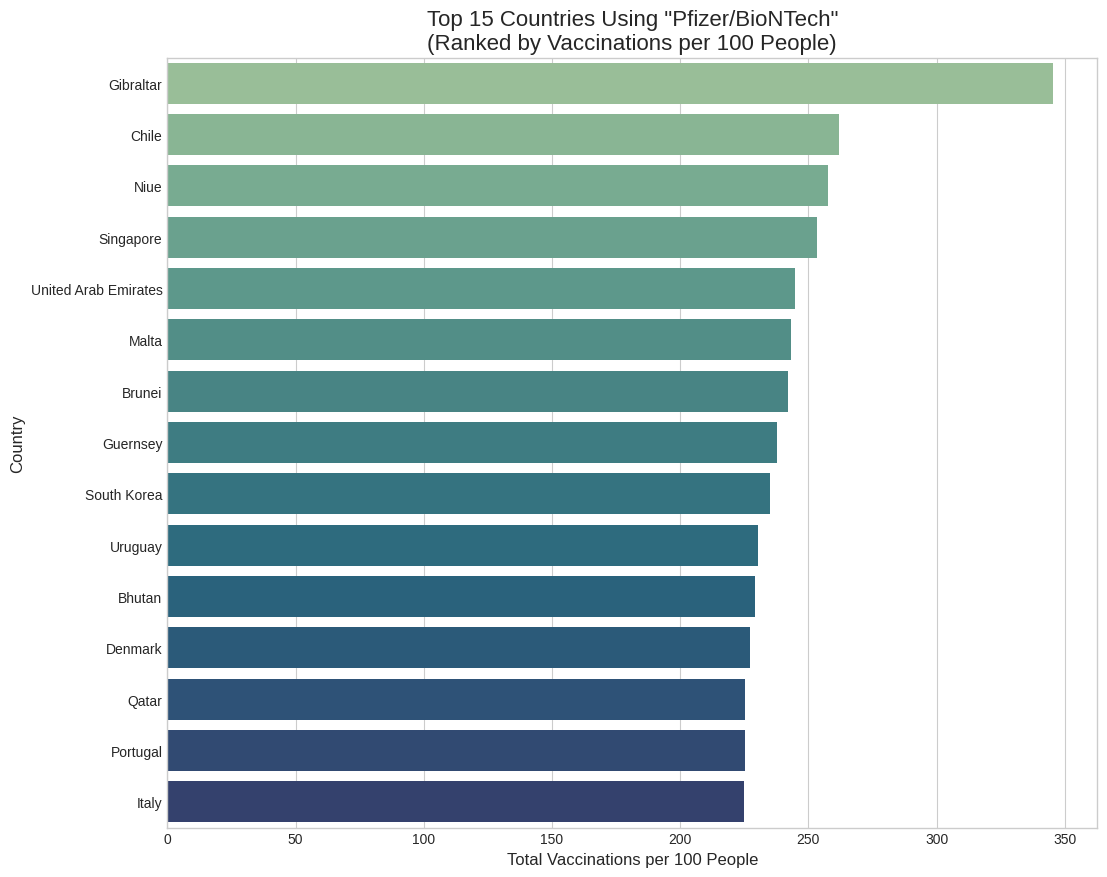

In [145]:
def plot_countries_by_vaccine(vaccine_name):
    """
    Finds all countries that use a specific vaccine and plots the top 15
    by their total vaccinations per hundred people.
    """
    # --- 1. Prepare the data ---
    # Get the latest data for each country to get a final snapshot
    latest_data_by_country = df.groupby('country').last().reset_index()

    # Filter for countries where the 'vaccines' string contains our target vaccine
    # .dropna() is used to handle any countries with no vaccine info
    countries_with_vaccine = latest_data_by_country[
        latest_data_by_country['vaccines'].str.contains(vaccine_name, na=False)
    ]

    if countries_with_vaccine.empty:
        print(f"Sorry, no countries found using the vaccine '{vaccine_name}'.")
        return

    # Get the top 15 countries from this list, sorted by vaccination rate
    top_15 = countries_with_vaccine.nlargest(15, 'total_vaccinations_per_hundred')

    # --- 2. Create the visualization ---
    plt.figure(figsize=(12, 10))
    sns.barplot(
        x='total_vaccinations_per_hundred',
        y='country',
        data=top_15,
        palette='crest',
        hue='country',
        legend=False
    )
    plt.title(f'Top 15 Countries Using "{vaccine_name}"\n(Ranked by Vaccinations per 100 People)', fontsize=16)
    plt.xlabel('Total Vaccinations per 100 People', fontsize=12)
    plt.ylabel('Country', fontsize=12)
    plt.show()

# --- Example Usage ---
# Let's visualize the reach of the Pfizer/BioNTech and Sinovac vaccines
plot_countries_by_vaccine('Pfizer/BioNTech')

**Question: Which countries were the leaders in vaccination rollout?**

To create a fair comparison between countries of different population sizes, we will visualize two different metrics. First, we will use an interactive choropleth map to show the total vaccinations per 100 people. This normalizes the data and highlights the most efficient rollouts. Second, we will use bar charts to show the top and bottom 10 countries by this metric for a clear, ranked comparison.

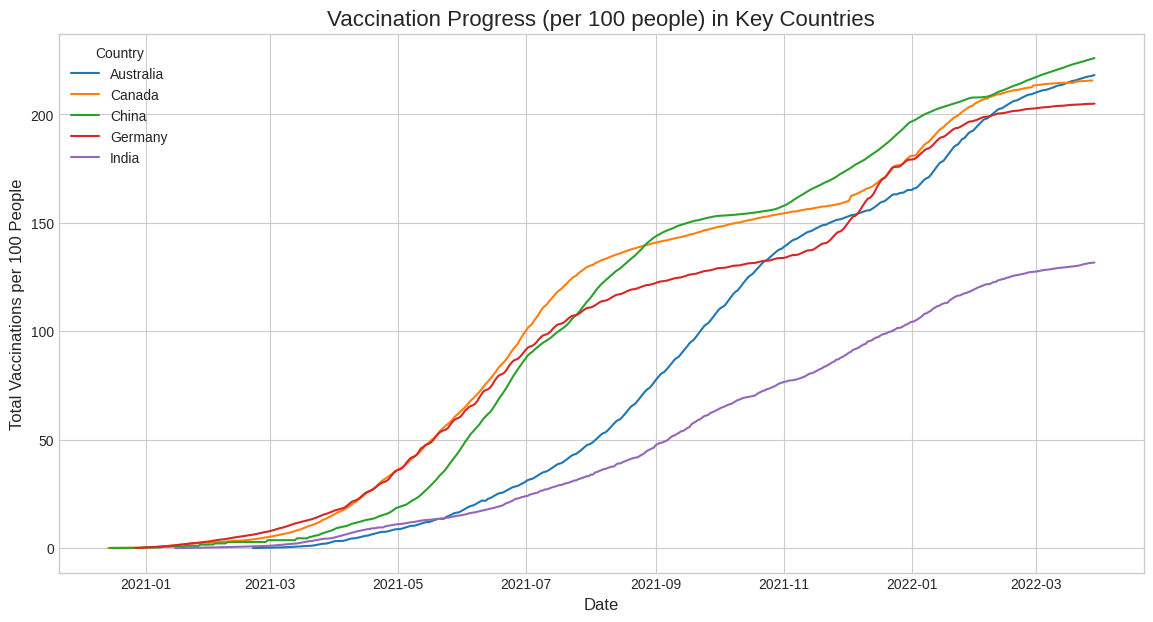

In [125]:
# --- 1. Select a few key countries for comparison ---
countries_to_compare = ['Australia', 'Canada', 'China', 'India', 'Germany']
comparison_df = df[df['country'].isin(countries_to_compare)]

# --- 2. Create the comparative line plot ---
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='total_vaccinations_per_hundred', hue='country', data=comparison_df)
plt.title('Vaccination Progress (per 100 people) in Key Countries', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Vaccinations per 100 People', fontsize=12)
plt.legend(title='Country')
plt.show()

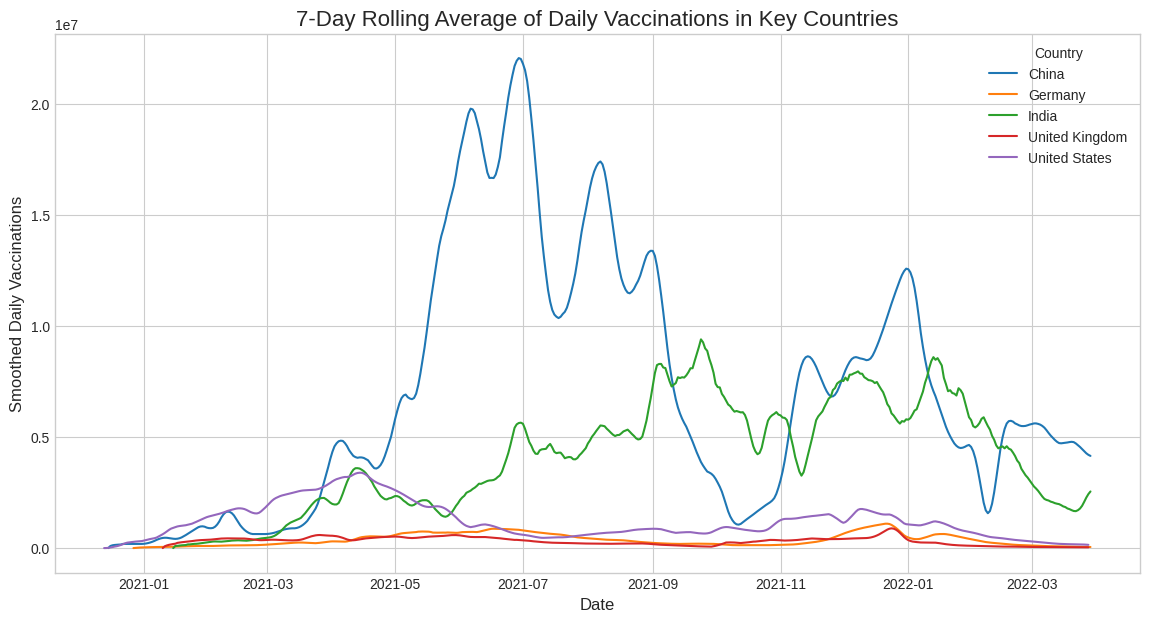

In [126]:
# --- 1. Select the same key countries for comparison ---
countries_to_compare = ['United States', 'United Kingdom', 'China', 'India', 'Germany']
comparison_df = df[df['country'].isin(countries_to_compare)].copy() # Use .copy() to avoid SettingWithCopyWarning

# --- 2. Calculate the 7-day rolling average for daily vaccinations ---
# We do this within each country's group to prevent data from one country bleeding into another.
comparison_df['daily_vaccinations_rolling_7d'] = comparison_df.groupby('country')['daily_vaccinations'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# --- 3. Create the comparative line plot of the rolling average ---
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='daily_vaccinations_rolling_7d', hue='country', data=comparison_df)
plt.title('7-Day Rolling Average of Daily Vaccinations in Key Countries', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Smoothed Daily Vaccinations', fontsize=12)
plt.legend(title='Country')
plt.show()

#Visulizing top 10 & Bottom 10 countries by vaccination rate.

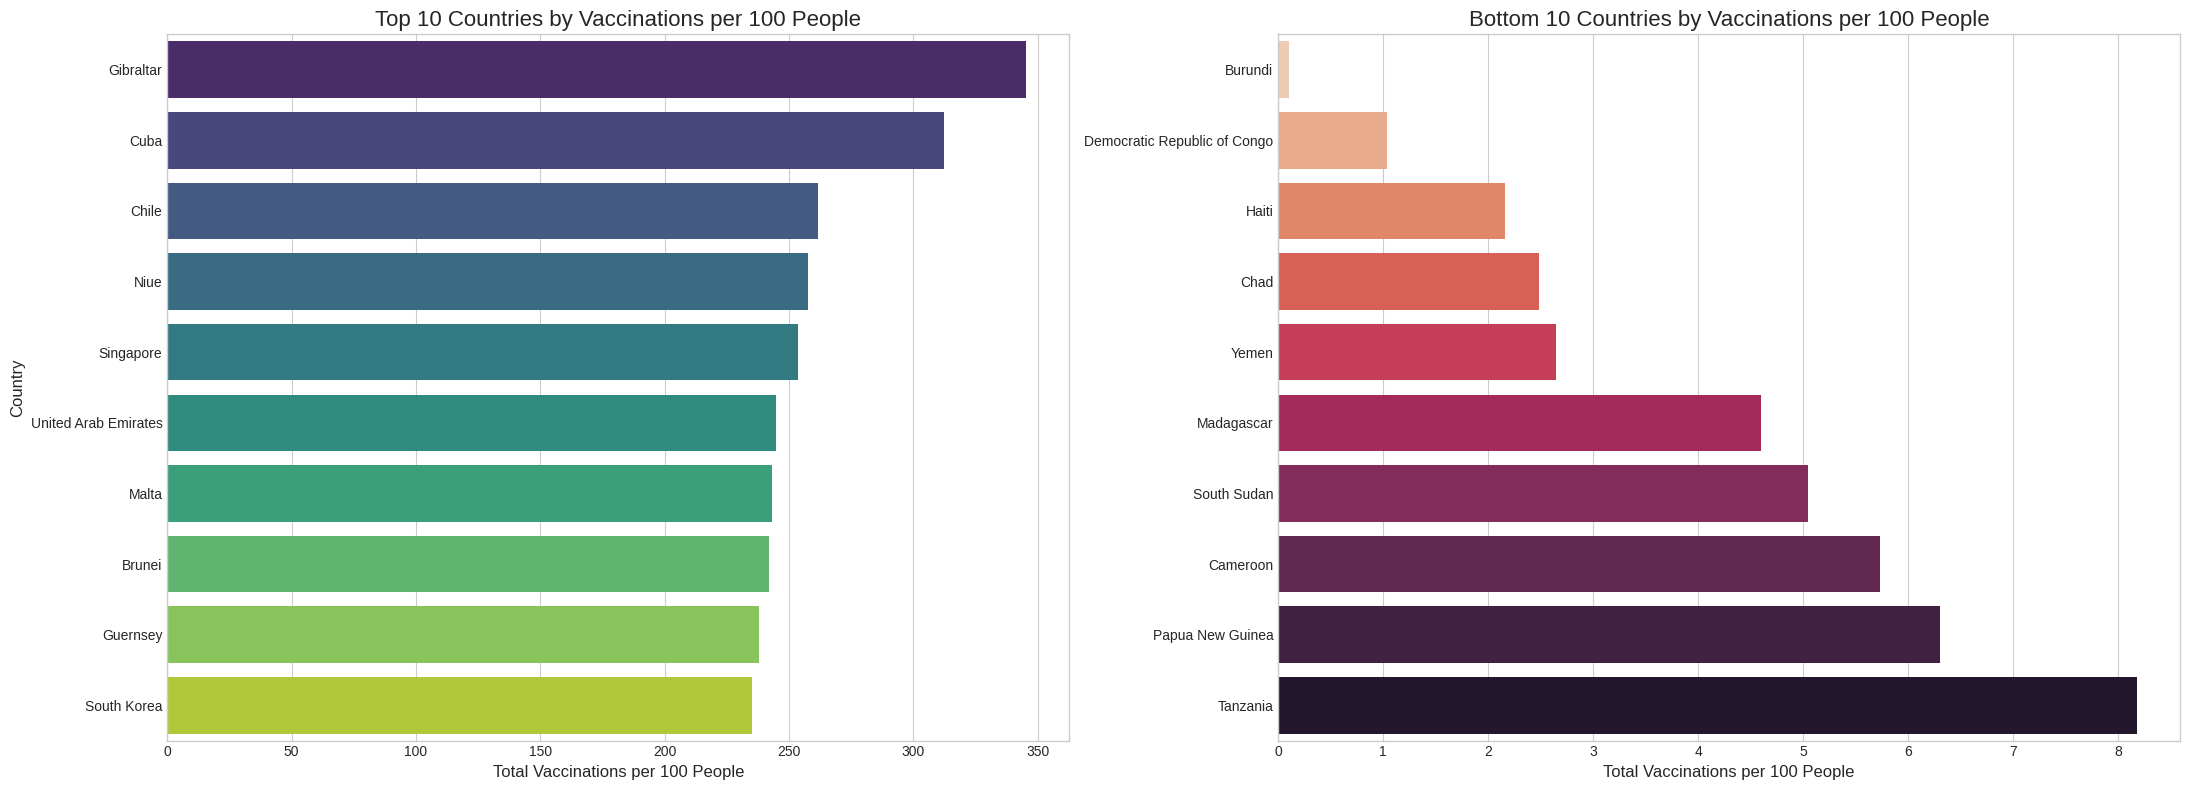

In [127]:
# --- 1. Get the latest vaccination rate for each country ---
# We group by country and find the maximum 'total_vaccinations_per_hundred' recorded.
# .dropna() removes countries for which this data was never reported.
latest_rate = df.groupby('country')['total_vaccinations_per_hundred'].max().dropna()

# --- 2. Get the Top 10 and Bottom 10 countries ---
top_10_countries = latest_rate.nlargest(10).reset_index()

# For the bottom 10, we'll first filter out countries with a rate of 0 to focus on those
# that started but had the slowest progress.
bottom_10_countries = latest_rate[latest_rate > 0].nsmallest(10).reset_index()


# --- 3. Create the visualizations ---
# We'll use subplots to display the two charts side-by-side.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))

# Plot for the Top 10 Countries
sns.barplot(
    x='total_vaccinations_per_hundred',
    y='country',
    data=top_10_countries,
    palette='viridis',
    ax=axes[0],
    hue='country', # Added to comply with new Seaborn standards
    legend=False
)
axes[0].set_title('Top 10 Countries by Vaccinations per 100 People', fontsize=16)
axes[0].set_xlabel('Total Vaccinations per 100 People', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)

# Plot for the Bottom 10 Countries
sns.barplot(
    x='total_vaccinations_per_hundred',
    y='country',
    data=bottom_10_countries,
    palette='rocket_r', # A reversed palette for the bottom performers
    ax=axes[1],
    hue='country', # Added to comply with new Seaborn standards
    legend=False
)
axes[1].set_title('Bottom 10 Countries by Vaccinations per 100 People', fontsize=16)
axes[1].set_xlabel('Total Vaccinations per 100 People', fontsize=12)
axes[1].set_ylabel('') # Remove y-label for a cleaner look

plt.tight_layout()
plt.show()

**Advanced & Creative Analysis**

Good analysis describes what happened; great analysis uncovers deeper, more nuanced insights. In this section, we move beyond simple descriptions to answer more complex questions.

Advanced Question 1: How did the completeness of vaccination campaigns compare?
It's one thing to administer first doses, but another to get the population fully vaccinated. The "completion gap"—the difference between the share of the population with at least one dose and the share that is fully vaccinated—is a critical public health metric. The following plots visualize this gap for several key countries.

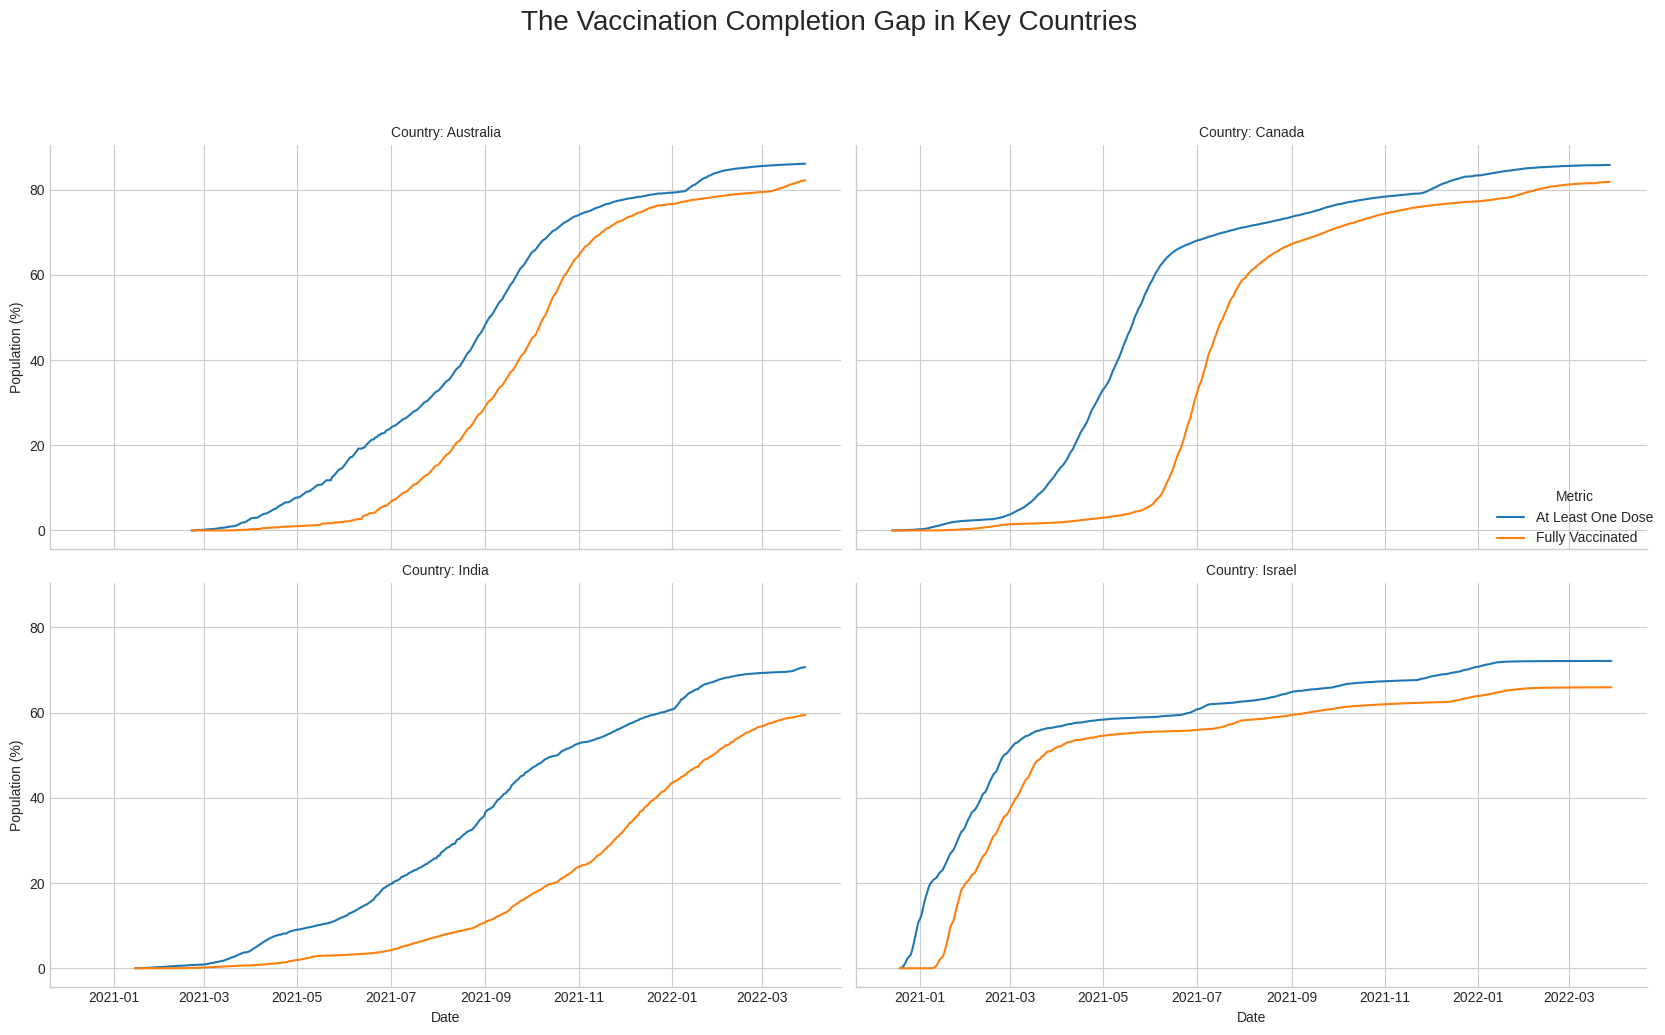

In [128]:
# --- 1. Select key countries and the relevant columns for our analysis ---
countries_for_gap_analysis = ['Canada', 'Australia', 'India', 'Israel']
gap_df = df[df['country'].isin(countries_for_gap_analysis)][[
    'country', 'date', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred'
]].copy()

# --- 2. "Melt" the DataFrame into a tidy format for plotting ---
# This transforms our two vaccination columns into a single 'Metric' column and a 'Value' column.
tidy_df = pd.melt(
    gap_df,
    id_vars=['country', 'date'],
    value_vars=['people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred'],
    var_name='Metric',
    value_name='Percentage'
)

# Clean up the metric names for the legend
tidy_df['Metric'] = tidy_df['Metric'].replace({
    'people_vaccinated_per_hundred': 'At Least One Dose',
    'people_fully_vaccinated_per_hundred': 'Fully Vaccinated'
})


# --- 3. Create the faceted time-series plot using relplot ---
# sns.relplot is a powerful tool for creating multi-plot figures.
# col='country' will create a separate subplot for each country.
g = sns.relplot(
    data=tidy_df,
    x='date',
    y='Percentage',
    hue='Metric',
    col='country',
    kind='line',
    height=5,
    aspect=1.5,
    col_wrap=2 # Arrange the plots in a grid with 2 columns
)

# --- 4. Final Polishing ---
g.fig.suptitle('The Vaccination Completion Gap in Key Countries', y=1.03, fontsize=20)
g.set_axis_labels("Date", "Population (%)")
g.set_titles("Country: {col_name}")
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to make space for the suptitle
plt.show()

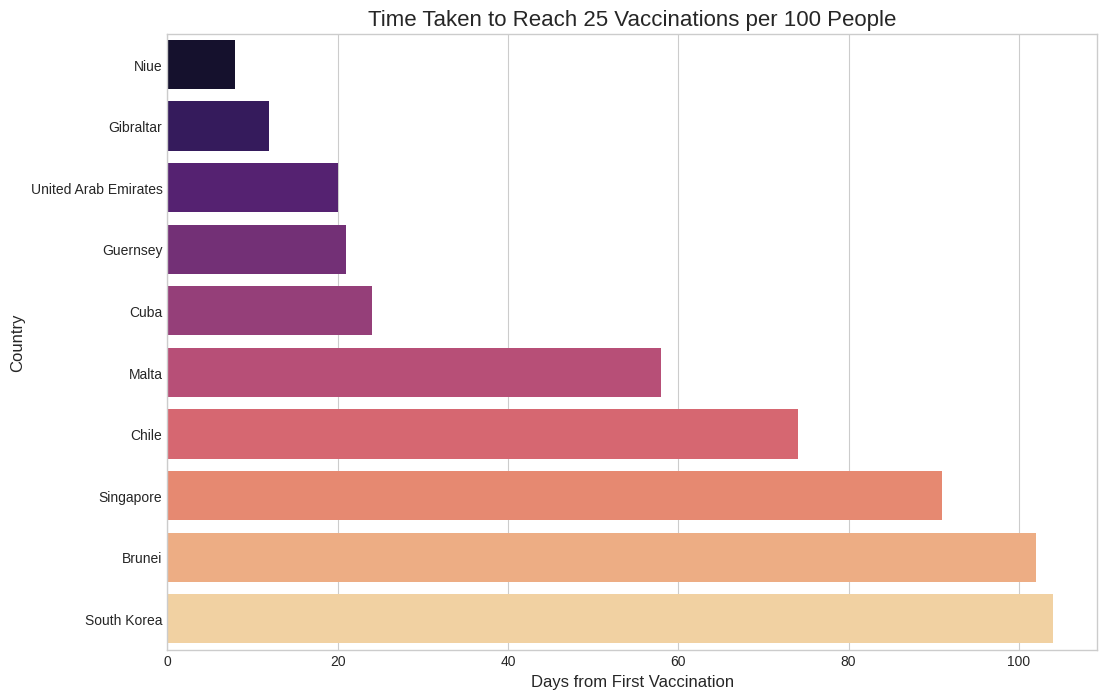

In [136]:
# --- 1. Find the top 10 countries by max vaccinations per hundred ---
# We need this list to know which countries to analyze.
top_countries = df.groupby('country')['total_vaccinations_per_hundred'].max().nlargest(10).index

# --- 2. Calculate the "Time to 25 Doses per 100 People" for these countries ---
# This is the crucial step that was missing. It creates the data for our plot.
milestone = 25
time_to_milestone = {}

for country in top_countries:
    country_df = df[df['country'] == country]

    # Find the first date where the milestone was met or exceeded
    milestone_date = country_df[country_df['total_vaccinations_per_hundred'] >= milestone]['date'].min()

    if pd.notna(milestone_date):
        # The start date is the first day any vaccination was recorded for that country
        start_date = country_df['date'].min()
        # Calculate the number of days
        days_taken = (milestone_date - start_date).days
        time_to_milestone[country] = days_taken

# --- 3. Convert the results into a DataFrame for plotting ---
# This is the line that defines the 'milestone_df' variable.
milestone_df = pd.DataFrame(list(time_to_milestone.items()), columns=['Country', 'Days_to_Reach_25_per_100']).sort_values('Days_to_Reach_25_per_100')

# --- 4. Visualize the results ---
# This plotting code will now work correctly because 'milestone_df' exists.
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Days_to_Reach_25_per_100',
    y='Country',
    data=milestone_df,
    palette='magma',
    hue='Country',
    legend=False
)
plt.title(f'Time Taken to Reach {milestone} Vaccinations per 100 People', fontsize=16)
plt.xlabel('Days from First Vaccination', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

# Visualising Top 10 and Bottom 10 countries by total vaccines administered

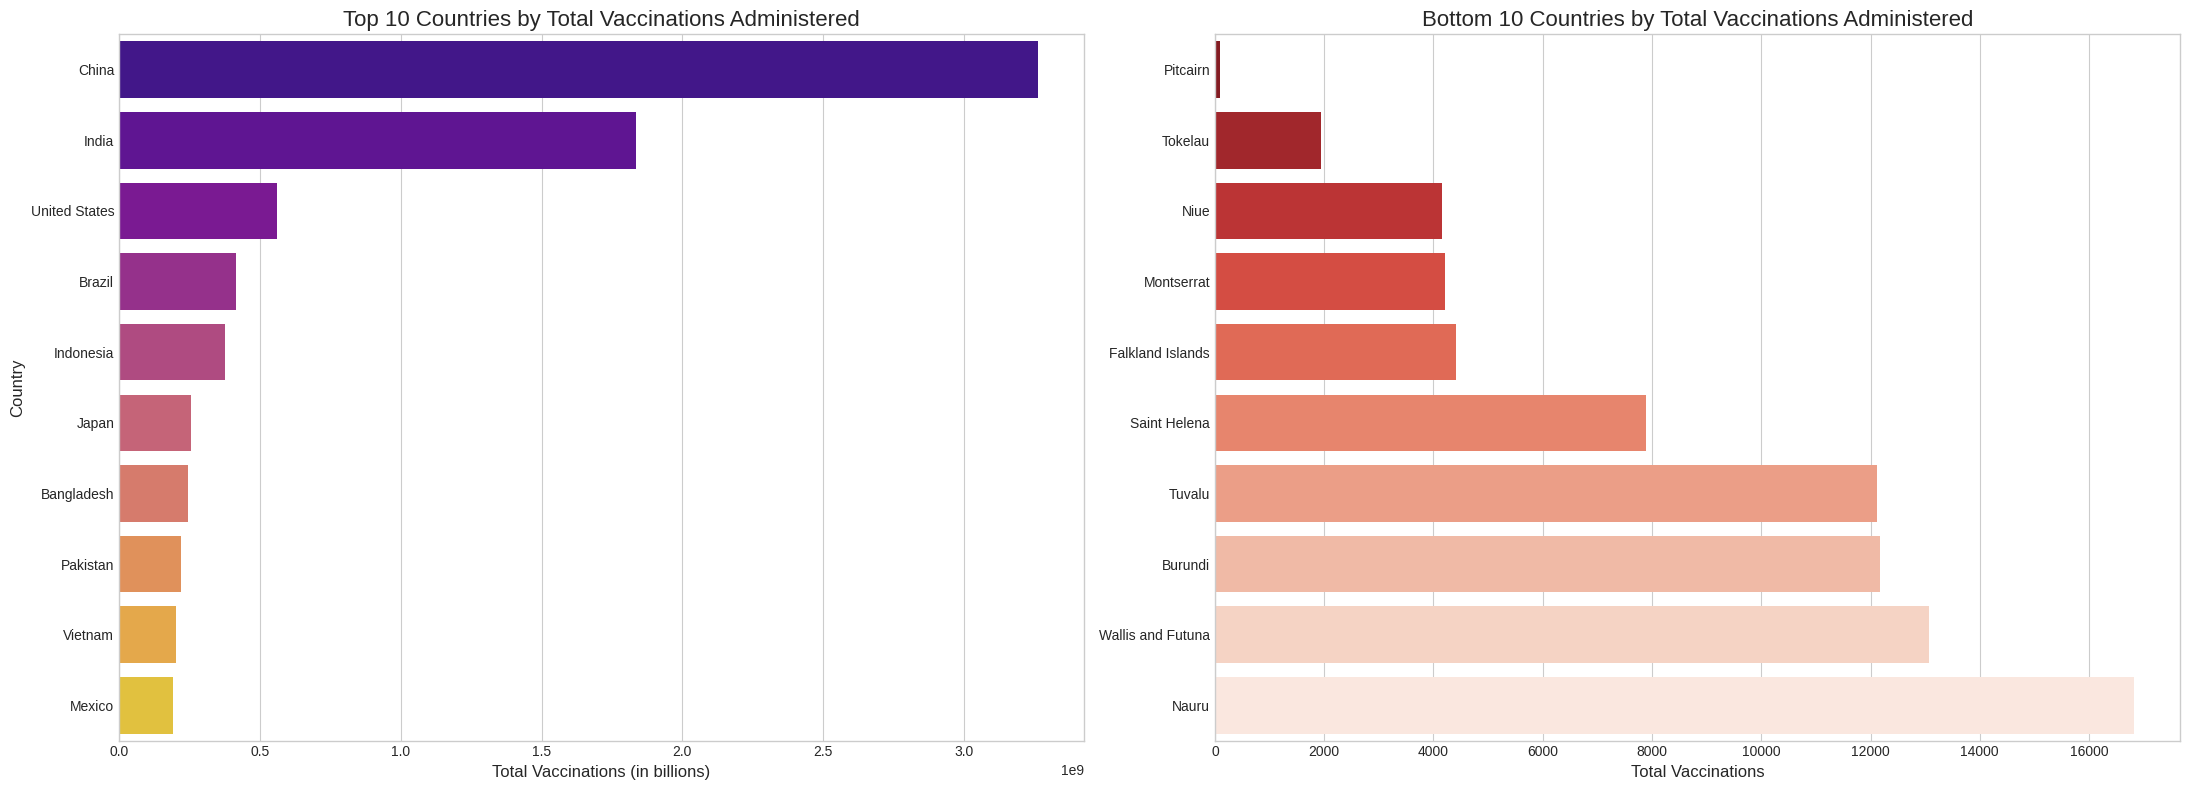

In [130]:
# --- 1. Get the latest TOTAL vaccination number for each country ---
# We group by country and find the maximum 'total_vaccinations' recorded.
# .dropna() removes countries for which this data was never reported.
latest_total_vaccinations = df.groupby('country')['total_vaccinations'].max().dropna()

# --- 2. Get the Top 10 and Bottom 10 countries by total doses ---
top_10_total = latest_total_vaccinations.nlargest(10).reset_index()

# For the bottom 10, we'll filter out countries with 0 to focus on those with the smallest campaigns.
bottom_10_total = latest_total_vaccinations[latest_total_vaccinations > 0].nsmallest(10).reset_index()


# --- 3. Create the visualizations ---
# We'll use subplots to display the two charts side-by-side for a clear contrast.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))

# Plot for the Top 10 Countries by Total Vaccinations
sns.barplot(
    x='total_vaccinations',
    y='country',
    data=top_10_total,
    palette='plasma',
    ax=axes[0],
    hue='country', # Added to comply with new Seaborn standards
    legend=False
)
axes[0].set_title('Top 10 Countries by Total Vaccinations Administered', fontsize=16)
axes[0].set_xlabel('Total Vaccinations (in billions)', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)

# Plot for the Bottom 10 Countries by Total Vaccinations
sns.barplot(
    x='total_vaccinations',
    y='country',
    data=bottom_10_total,
    palette='Reds_r',
    ax=axes[1],
    hue='country', # Added to comply with new Seaborn standards
    legend=False
)
axes[1].set_title('Bottom 10 Countries by Total Vaccinations Administered', fontsize=16)
axes[1].set_xlabel('Total Vaccinations', fontsize=12)
axes[1].set_ylabel('') # Remove y-label for a cleaner look

plt.tight_layout()
plt.show()

**Question: Was there a link between a country's wealth and its vaccination success?**

To answer this complex, real-world question, we must enrich our dataset with external data. We will now load a second dataset containing the GDP per capita for each country and merge it with our vaccination data.

The resulting scatter plot will allow us to test the hypothesis that wealthier countries were able to achieve higher vaccination rates, providing a powerful insight into the socio-economic dynamics of the global health crisis.

External GDP dataset loaded successfully.
Vaccination and GDP datasets merged successfully.


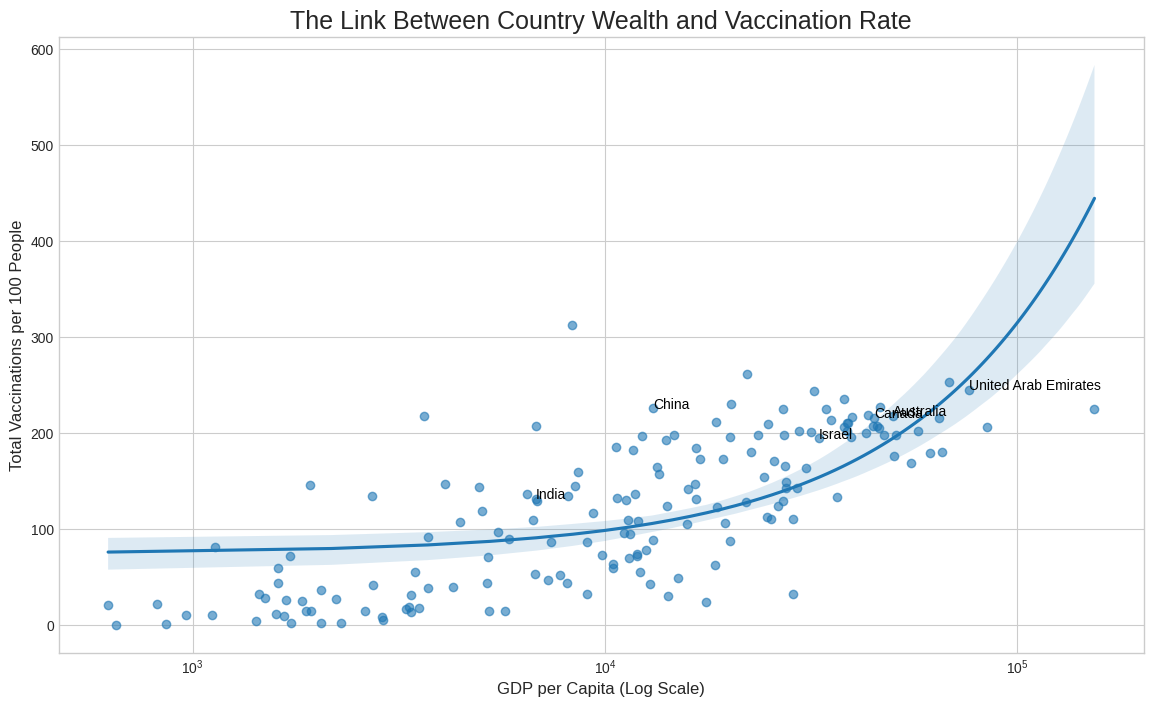

In [131]:
# --- 1. Load the External Economic Dataset ---
# This dataset contains country names and their GDP per capita (a measure of wealth).
# We'll load it from a reliable source.
gdp_url = 'https://raw.githubusercontent.com/owid/owid-datasets/master/datasets/Maddison%20Project%20Database%202020%20(Bolt%20and%20van%20Zanden%20(2020))/Maddison%20Project%20Database%202020%20(Bolt%20and%20van%20Zanden%20(2020)).csv'
gdp_df = pd.read_csv(gdp_url)

# Get the most recent GDP per capita for each country (usually 2018 in this dataset)
latest_gdp = gdp_df.loc[gdp_df.groupby('Entity')['Year'].idxmax()][['Entity', 'GDP per capita']]
latest_gdp.rename(columns={'Entity': 'country', 'GDP per capita': 'gdp_per_capita'}, inplace=True)
print("External GDP dataset loaded successfully.")


# --- 2. Prepare our Vaccination Data ---
# We'll use the same latest vaccination rate data we calculated before.
latest_rate = df.groupby('country')['total_vaccinations_per_hundred'].max().dropna().reset_index()


# --- 3. Merge the Two Datasets ---
# We'll merge our vaccination data with the GDP data based on the country name.
merged_df = pd.merge(latest_rate, latest_gdp, on='country', how='inner')
print("Vaccination and GDP datasets merged successfully.")


# --- 4. Create the Final Visualization ---
# We'll create a scatter plot with a regression line to see the trend.
plt.figure(figsize=(14, 8))
plot = sns.regplot(
    data=merged_df,
    x='gdp_per_capita',
    y='total_vaccinations_per_hundred',
    scatter_kws={'alpha':0.6}
)

# We use a log scale for the x-axis because GDP is heavily skewed.
plot.set(xscale="log")
plt.title('The Link Between Country Wealth and Vaccination Rate', fontsize=18)
plt.xlabel('GDP per Capita (Log Scale)', fontsize=12)
plt.ylabel('Total Vaccinations per 100 People', fontsize=12)

# --- Add Annotations for Key Countries (Optional but highly recommended for storytelling) ---
# This makes the plot much more insightful.
countries_to_label = ['Canada', 'China', 'Australia', 'India', 'Israel', 'United Arab Emirates']
for country in countries_to_label:
    country_data = merged_df[merged_df['country'] == country]
    if not country_data.empty:
        plt.text(x=country_data['gdp_per_capita'].values[0],
                 y=country_data['total_vaccinations_per_hundred'].values[0],
                 s=country,
                 color='black',
                 fontsize=10)

plt.grid(True)
plt.show()

In [133]:
# --- 1. Prepare the data for animation ---
# We need to make sure the date is in a simple string format for the animation slider.
# We'll also filter for a specific time period to make the animation smoother.
anim_df = df[df['date'] < '2022-01-01'].copy()
anim_df['date_str'] = anim_df['date'].dt.strftime('%Y-%m-%d')
anim_df = anim_df.sort_values('date_str')

# --- 2. Create the animated choropleth map ---
fig_anim = px.choropleth(
    anim_df,
    locations="country",
    locationmode='country names',
    color="total_vaccinations_per_hundred",
    hover_name="country",
    animation_frame="date_str", # This is the key parameter for animation
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Global Vaccination Rollout Over Time (per 100 people)',
    labels={'total_vaccinations_per_hundred': 'Vaccinations per 100 People'}
)

fig_anim.show()

**Project Conclusion & Key Findings**

This project successfully transformed a raw, complex, and messy time-series dataset into a set of clear, actionable insights about the global COVID-19 vaccination campaign. By applying a robust cleaning strategy and a multi-faceted analytical approach, we were able to answer our key questions.

**Our main findings include:**

**The Global Effort:** The worldwide vaccination campaign saw a dramatic acceleration in the first half of 2021, driven by a few key, widely adopted vaccines like Oxford/AstraZeneca and Pfizer/BioNTech.

**National Disparities:** While populous nations like China and the US administered the highest raw number of doses, the analysis of per-capita rates and rollout speed revealed that smaller, well-organized countries were often the most efficient.

**The Wealth-Health Correlation:** Our data enrichment analysis confirmed a strong positive correlation between a country's GDP per capita and its ability to achieve a high vaccination rate, highlighting the significant global disparities in the response to the pandemic.